In [1]:
import pandas as pd
import numpy as np
import pickle

In [2]:
app = pd.read_csv('application_record.csv')
credit = pd.read_csv('credit_record.csv')

## Target preparation

In [3]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [4]:
credit['ID'].nunique()

45985

In [5]:
credit['bad_flag'] = credit['STATUS'].apply(lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0)
target_df = credit.groupby('ID').agg({'bad_flag':'max'})
target_df.head()

,bad_flag
ID,
5001711,0
5001712,0
5001713,0
5001714,0
5001715,0


In [6]:
df = app.merge(target_df, on='ID', how='left')
assert app.shape[0] == df.shape[0]
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,bad_flag
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0.0


In [7]:
df['bad_flag'].value_counts()

bad_flag
0.0    32166
1.0     4291
Name: count, dtype: int64

In [8]:
df['bad_flag'].isnull().sum()

np.int64(402100)

In [9]:
df = df[df['bad_flag'].notna()]

### Feature engineering

In [10]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,bad_flag
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0.0


In [11]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'bad_flag'],
      dtype='str')

In [12]:
df['OCCUPATION_TYPE'].unique()

<StringArray>
[                    nan,        'Security staff',           'Sales staff',
           'Accountants',              'Laborers',              'Managers',
               'Drivers',            'Core staff', 'High skill tech staff',
        'Cleaning staff', 'Private service staff',         'Cooking staff',
    'Low-skill Laborers',        'Medicine staff',           'Secretaries',
  'Waiters/barmen staff',              'HR staff',         'Realty agents',
              'IT staff']
Length: 19, dtype: str

In [13]:
df['NAME_FAMILY_STATUS'].unique()

<StringArray>
['Civil marriage', 'Married', 'Single / not married', 'Separated', 'Widow']
Length: 5, dtype: str

In [14]:
df['CODE_GENDER'].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [15]:
categorical_columns = df.columns[df.dtypes == 'str']
print(df[categorical_columns].nunique())
# print(df[categorical_columns].isnull().sum())

df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')
# df_encoded = pd.get_dummies(df, 
#                             columns=[i for i in categorical_columns if i!='OCCUPATION_TYPE'],
#                             dummy_na=False)

CODE_GENDER             2
FLAG_OWN_CAR            2
FLAG_OWN_REALTY         2
NAME_INCOME_TYPE        5
NAME_EDUCATION_TYPE     5
NAME_FAMILY_STATUS      5
NAME_HOUSING_TYPE       6
OCCUPATION_TYPE        18
dtype: int64


In [37]:
df['AGE'] = -1 * df['DAYS_BIRTH'] / 365
df.drop(columns=['DAYS_BIRTH'], inplace=True)

In [40]:
df['YEARS_EMPLOYED'] = -1 * df['DAYS_EMPLOYED'] / 365
df.drop(columns=['DAYS_EMPLOYED'], inplace=True)

In [41]:
df['AGE']

0         32.890411
1         32.890411
2         58.832877
3         52.356164
4         52.356164
            ...    
434808    47.528767
434809    33.936986
434810    33.936986
434811    49.200000
434812    25.172603
Name: AGE, Length: 36457, dtype: float64

## Train_model

In [42]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

X = df.drop(columns=['bad_flag', 'ID'])
y = df['bad_flag'].astype(int)

# Определяем категориальные и числовые признаки
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

for col in categorical_features:
    X[col] = X[col].astype('category')

categorical_indices = [X.columns.get_loc(col) for col in categorical_features]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9},
    {'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9},
]

best_score = -1
best_params = None
best_fold_scores = None
best_model = None

for params in param_grid:
    fold_scores = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        # Создаем модель с указанием категориальных признаков
        model = lgb.LGBMClassifier(
            objective='binary',
            boosting_type='gbdt',
            n_estimators=5000,
            max_depth = 4,
            metric='auc',
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            # categorical_feature=categorical_indices,
            **params
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0.001)]
        )

        proba = model.predict_proba(X_valid)[:, 1]
        fold_scores.append(roc_auc_score(y_valid, proba))

    mean_score = round(float(np.mean(fold_scores)), 4)
    print(f"params={params} | mean_cv_auc={mean_score}")

    if mean_score > best_score:
        best_model = model
        best_score = mean_score
        best_params = params
        best_fold_scores = fold_scores

print('Best params:', best_params)
print('Fold AUC scores:', best_fold_scores)
print('Mean CV AUC:', best_score)

C:\Users\ulyan\AppData\Local\Temp\ipykernel_16348\2392593429.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1762]	valid_0's auc: 0.727892
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2697]	valid_0's auc: 0.733824
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2741]	valid_0's auc: 0.739788
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2674]	valid_0's auc: 0.729698
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2058]	valid_0's auc: 0.722975
params={'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8} | mean_cv_auc=0.7308
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2018]	valid_0's auc: 0.731057
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3029]	valid_0's auc: 0.736128
Training until v

In [43]:
categorical_features

['CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE']

In [56]:
best_model

,max_depth,4
,learning_rate,0.05
,n_estimators,5000
,objective,'binary'
,subsample,0.9
,colsample_bytree,0.9
,random_state,42
,n_jobs,-1
,metric,'auc'
,verbose,-1
,boosting_type,'gbdt'


In [45]:
# Получить важности признаков
importances = best_model.feature_importances_

# Создать DataFrame для удобного просмотра
feature_importance_df = pd.DataFrame({
    'feature': best_model.feature_name_,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df)

                feature  importance
15                  AGE        8627
16       YEARS_EMPLOYED        7473
4      AMT_INCOME_TOTAL        6303
13      OCCUPATION_TYPE        2780
14      CNT_FAM_MEMBERS        1074
3          CNT_CHILDREN         913
2       FLAG_OWN_REALTY         729
1          FLAG_OWN_CAR         702
11           FLAG_PHONE         654
7    NAME_FAMILY_STATUS         622
10      FLAG_WORK_PHONE         586
0           CODE_GENDER         523
5      NAME_INCOME_TYPE         479
6   NAME_EDUCATION_TYPE         435
8     NAME_HOUSING_TYPE         385
12           FLAG_EMAIL         321
9            FLAG_MOBIL           0


Matplotlib is building the font cache; this may take a moment.


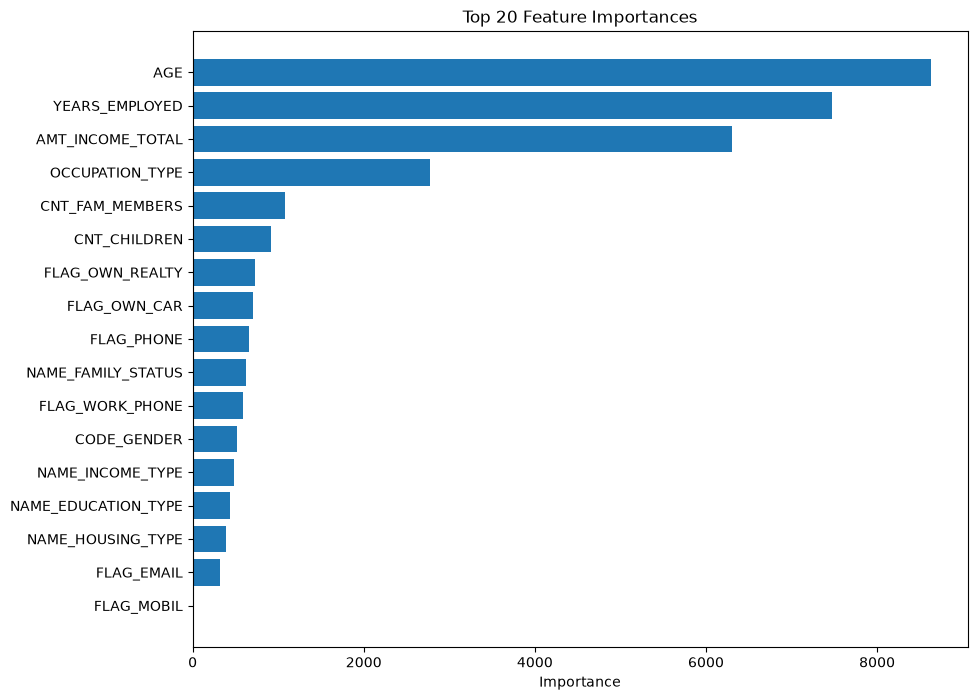

In [48]:
import matplotlib.pyplot as plt

# Топ-20 признаков
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances')
plt.gca().invert_yaxis()  # чтобы самый важный был сверху
plt.show()

In [51]:
with open('assets/model.pkl', 'wb') as file:
    pickle.dump(best_model, file)